In [1]:
import time
import requests
from concurrent.futures import ThreadPoolExecutor

urls = [
    "https://www.google.com",
    "https://www.python.org",
    "https://www.github.com"
]

def fetch_status(url):
    print(f"Fetching {url}...")
    start_time = time.time()
    resp = requests.get(url)
    end_time = time.time()
    duration = end_time - start_time
    return f"{url}: {resp.status_code} (took {duration:.2f} seconds)"

print("--- Sequential Execution ---")
sequential_start_time = time.time()
sequential_results = []
for url in urls:
    sequential_results.append(fetch_status(url))
sequential_end_time = time.time()

for result in sequential_results:
    print(result)
print(f"Total sequential execution time: {sequential_end_time - sequential_start_time:.2f} seconds")

print("--- Concurrent Execution ---")
concurrent_start_time = time.time()
with ThreadPoolExecutor(max_workers=3) as executor:
    concurrent_results = list(executor.map(fetch_status, urls))
concurrent_end_time = time.time()
for result in concurrent_results:
    print(result)
print(f"Total concurrent execution time: {concurrent_end_time - concurrent_start_time:.2f} seconds\n")

--- Sequential Execution ---
Fetching https://www.google.com...
Fetching https://www.python.org...
Fetching https://www.github.com...
https://www.google.com: 200 (took 0.07 seconds)
https://www.python.org: 200 (took 0.03 seconds)
https://www.github.com: 200 (took 0.07 seconds)
Total sequential execution time: 0.16 seconds
--- Concurrent Execution ---
Fetching https://www.google.com...
Fetching https://www.python.org...
Fetching https://www.github.com...
https://www.google.com: 200 (took 0.05 seconds)
https://www.python.org: 200 (took 0.04 seconds)
https://www.github.com: 200 (took 0.09 seconds)
Total concurrent execution time: 0.09 seconds



In [6]:
import time
from concurrent.futures import ProcessPoolExecutor

def heavy_calculation(num):
    # Simulating a CPU-intensive task
    count = 0
    for i in range(10**7):
        count += i * num
    return count

data = [1, 2, 3, 4]

print("--- Sequential Execution (CPU-bound task) ---")
sequential_start = time.time()
sequential_results = []
for item in data:
    sequential_results.append(heavy_calculation(item))
sequential_end = time.time()

print(f"Sequential results: {sequential_results}")
print(f"Total sequential execution time: {sequential_end - sequential_start:.2f} seconds\n")

print("--- Concurrent Execution with ProcessPoolExecutor (CPU-bound task) ---")
concurrent_start = time.time()
with ProcessPoolExecutor() as executor:
    concurrent_results = list(executor.map(heavy_calculation, data))
concurrent_end = time.time()

print(f"Concurrent results: {concurrent_results}")
print(f"Total concurrent execution time: {concurrent_end - concurrent_start:.2f} seconds\n")

--- Sequential Execution (CPU-bound task) ---
Sequential results: [49999995000000, 99999990000000, 149999985000000, 199999980000000]
Total sequential execution time: 2.71 seconds

--- Concurrent Execution with ProcessPoolExecutor (CPU-bound task) ---
Concurrent results: [49999995000000, 99999990000000, 149999985000000, 199999980000000]
Total concurrent execution time: 0.73 seconds



In [3]:
import pandas as pd

def calculate_stats(series: pd.Series) -> pd.Series:
    # Calculate core metrics natively
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    stats = {
        'Mean (μ)': series.mean(),
        'Std Dev (σ)': series.std(),
        'Minimum': series.min(),
        'Q1 (25th)': q1,
        'Median (Q2)': series.median(),
        'Q3 (75th)': q3,
        'Maximum': series.max(),
        'IQR': q3 - q1
    }

    # Return as a Pandas Series for easy tabular comparison later
    return pd.Series(stats)

# --- The "Billionaire in a Bar" Example ---

# Create our Corrupted Dataset (with an added 'Age' column for context)
df_corrupted = pd.DataFrame({
    'Patron_ID': range(1, 12),
    'Age': [25, 34, 28, 45, 31, 52, 29, 38, 41, 27, 65],
    'Wealth_USD': [50000, 55000, 60000, 48000, 52000, 61000, 59000, 45000, 53000, 58000, 1000000000]
})

# Compute statistics for both scenarios simultaneously
comparison_df = pd.DataFrame({
    'Before Billionaire': calculate_stats(df_corrupted[:11]['Wealth_USD']),
    'After Billionaire': calculate_stats(df_corrupted['Wealth_USD'])})

comparison_df

,Before Billionaire,After Billionaire
Mean (μ),9.095827e+07,9.095827e+07
Std Dev (σ),3.014950e+08,3.014950e+08
Minimum,4.500000e+04,4.500000e+04
Q1 (25th),5.100000e+04,5.100000e+04
Median (Q2),5.500000e+04,5.500000e+04
Q3 (75th),5.950000e+04,5.950000e+04
Maximum,1.000000e+09,1.000000e+09
IQR,8.500000e+03,8.500000e+03


In [6]:
from ydata_profiling import ProfileReport

# Initialize the Profiling Report
# Setting explorative=True unlocks deeper statistical tests
profile = ProfileReport(
    df_corrupted,
    title="Bar Patron Wealth: Automated EDA Report",
    explorative=True)

# Export the interactive report to a static HTML file
# You can now open this file in Chrome, Safari, or share it with stakeholders
profile.to_file("wealth_distribution_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00, 394.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Generate a synthetic dataset (1,000 emails, 20 features)
# Labels (y): 0 = Safe Email, 1 = Spam Email
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# The Golden Rule in Action: Slicing the data 80/20
# X_train/y_train go into the training vault. X_test/y_test are quarantined.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Initialize our algorithm (A Random Forest with 100 decision trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model STRICTLY on the training vault
model.fit(X_train, y_train)

# Force the model to generate predictions on the quarantined test features
predictions = model.predict(X_test)
predictions

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1])

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Grade the exam by mathematically comparing predictions against the hidden answer key
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1:.2%}")

Accuracy: 90.00%
Precision: 94.85%
Recall: 85.98%
F1-Score: 90.20%


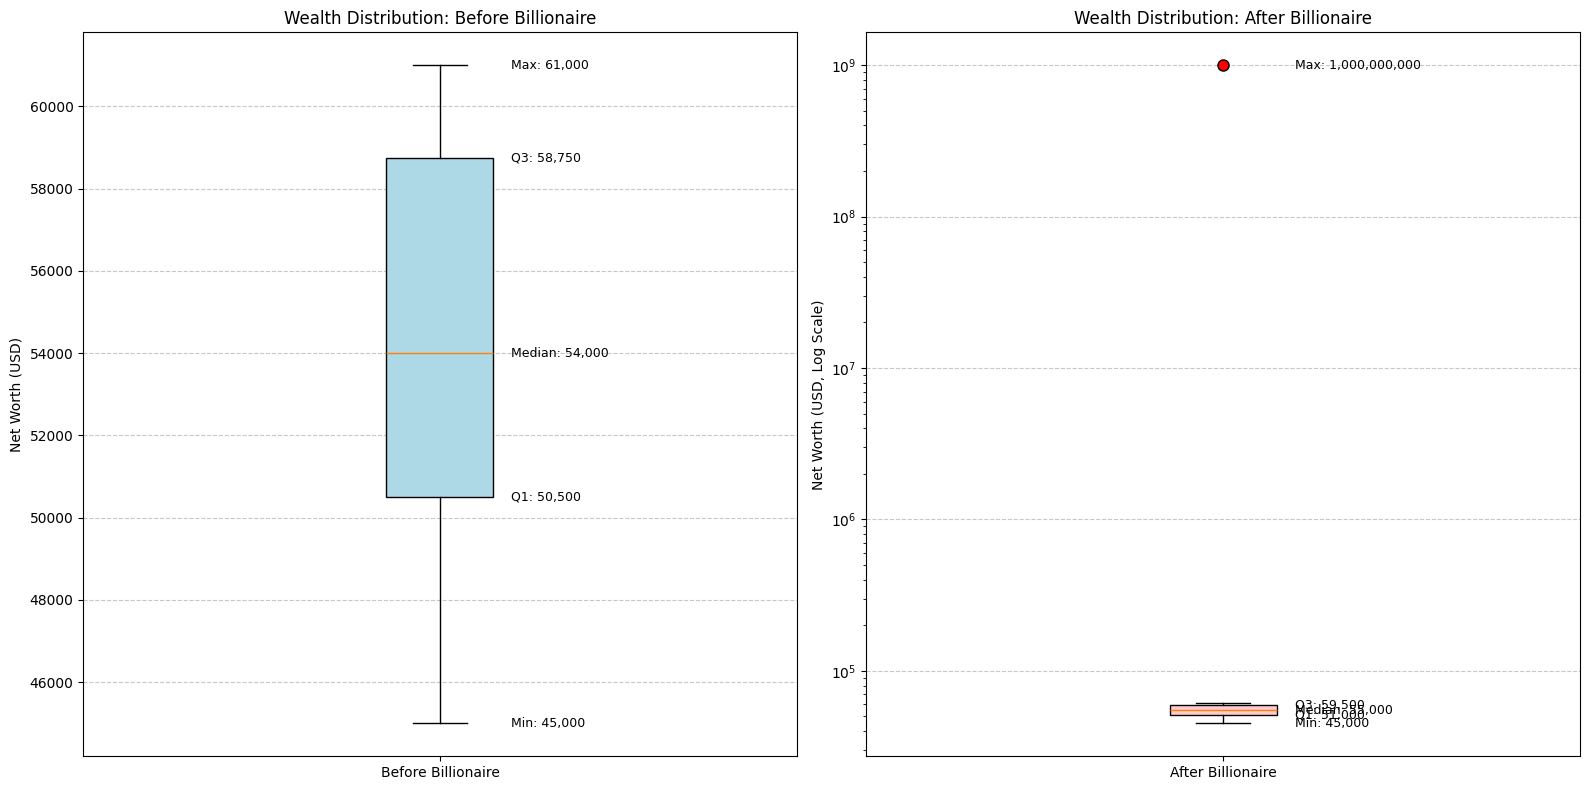

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Datasets
# Use the Wealth_USD column from the previously created DataFrames
wealth_base = df_corrupted[:11]['Wealth_USD']
wealth_corrupted = df_corrupted['Wealth_USD']

# 2. Initialize the Object-Oriented Canvas with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) # Increased figsize for better label visibility

# --- Plot for 'Before Billionaire' ---
ax1 = axes[0]
box1 = ax1.boxplot(
    wealth_base,
    tick_labels=['Before Billionaire'],
    patch_artist=True,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8}
)
for patch in box1['boxes']:
    patch.set_facecolor('#ADD8E6') # Light blue

# Calculate and label 5-number summary for wealth_base
min_base = wealth_base.min()
q1_base = wealth_base.quantile(0.25)
median_base = wealth_base.median()
q3_base = wealth_base.quantile(0.75)
max_base = wealth_base.max()

ax1.text(1.1, min_base, f'Min: {min_base:,.0f}', va='center', ha='left', fontsize=9)
ax1.text(1.1, q1_base, f'Q1: {q1_base:,.0f}', va='center', ha='left', fontsize=9)
ax1.text(1.1, median_base, f'Median: {median_base:,.0f}', va='center', ha='left', fontsize=9)
ax1.text(1.1, q3_base, f'Q3: {q3_base:,.0f}', va='center', ha='left', fontsize=9)
ax1.text(1.1, max_base, f'Max: {max_base:,.0f}', va='center', ha='left', fontsize=9)

ax1.set_ylabel('Net Worth (USD)')
ax1.set_title('Wealth Distribution: Before Billionaire')
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# --- Plot for 'After Billionaire' ---
ax2 = axes[1]
box2 = ax2.boxplot(
    wealth_corrupted,
    tick_labels=['After Billionaire'],
    patch_artist=True,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8}
)
for patch in box2['boxes']:
    patch.set_facecolor('#FFCCCB') # Light red

# Calculate and label 5-number summary for wealth_corrupted
min_corrupted = wealth_corrupted.min()
q1_corrupted = wealth_corrupted.quantile(0.25)
median_corrupted = wealth_corrupted.median()
q3_corrupted = wealth_corrupted.quantile(0.75)
max_corrupted = wealth_corrupted.max()

ax2.text(1.1, min_corrupted, f'Min: {min_corrupted:,.0f}', va='center', ha='left', fontsize=9)
ax2.text(1.1, q1_corrupted, f'Q1: {q1_corrupted:,.0f}', va='center', ha='left', fontsize=9)
ax2.text(1.1, median_corrupted, f'Median: {median_corrupted:,.0f}', va='center', ha='left', fontsize=9)
ax2.text(1.1, q3_corrupted, f'Q3: {q3_corrupted:,.0f}', va='center', ha='left', fontsize=9)
ax2.text(1.1, max_corrupted, f'Max: {max_corrupted:,.0f}', va='center', ha='left', fontsize=9)

ax2.set_yscale('log') # Log scale for the corrupted data
ax2.set_ylabel('Net Worth (USD, Log Scale)')
ax2.set_title('Wealth Distribution: After Billionaire')
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('wealth_distribution_boxplot.png')

# 7. Render the static image
plt.show()

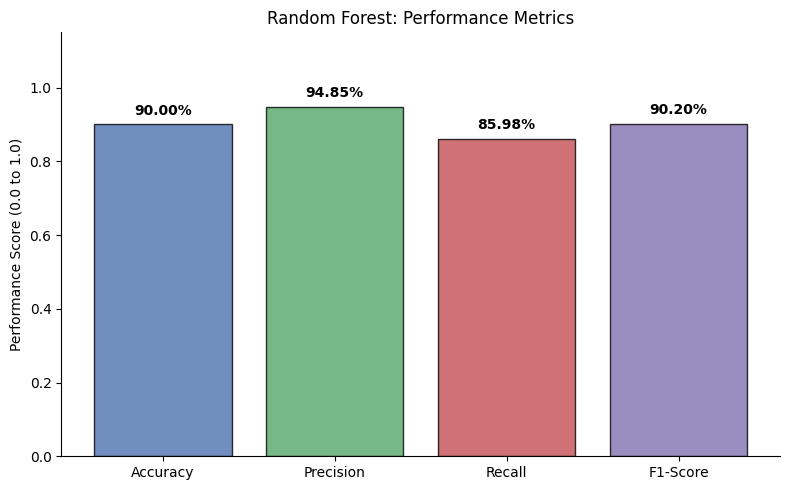

In [27]:
import matplotlib.pyplot as plt

# 1. Organize our previously calculated metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_scores = [accuracy, precision, recall, f1]

# 2. Initialize the Object-Oriented Canvas
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Build the Bar Chart
# We assign distinct, professional colors to differentiate the metrics
bars = ax.bar(
    metric_names,
    metric_scores,
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='black',
    alpha=0.8
)

# 4. Format the Axes
# We force the Y-axis to scale from 0 to 1.15 so we have headroom for our text labels
ax.set_ylim(0, 1.15)
ax.set_ylabel('Performance Score (0.0 to 1.0)')
ax.set_title('Random Forest: Performance Metrics')

# Remove the top and right borders (spines) for a cleaner, modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. The Engineering Touch: Annotating the exact percentages
# We loop through the physical 'bar' objects to find their height and center X-coordinates
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2%}',                      # The text to display (formatted as a %)
        xy=(bar.get_x() + bar.get_width() / 2, height), # (X, Y) coordinates
        xytext=(0, 5),                        # Nudge the text 5 points above the bar
        textcoords="offset points",
        ha='center', va='bottom',             # Center alignment
        fontweight='bold'
    )

# 6. Render the static image
plt.tight_layout()
plt.savefig('Random Forest: Performance Metrics.png')
plt.show()

In [33]:
# Setup Parameters (Simulating 10,000 days of pipeline runs)
# Vectorized Sampling: Pulling 10k random values for each stage
# We use max(value, 1) to ensure we don't simulate "negative" time
simulations = 10000
extraction_times = np.random.normal(45, 10, simulations)
transform_times = np.random.normal(90, 20, simulations)
load_times = np.random.normal(30, 5, simulations)

# Calculate the total pipeline duration for all 10,000 universes instantly
total_pipeline_times = extraction_times + transform_times + load_times

# Extracting the Engineering Metrics
sla_limit = 200
# Calculate the 95th percentile (The realistic worst-case scenario)
worst_case_95 = np.percentile(total_pipeline_times, 95)
# Calculate the exact probability of an SLA breach
breach_probability = np.mean(total_pipeline_times > sla_limit)

print(f"95th Percentile Run Time: {worst_case_95:.0f} minutes")
print(f"Probability of SLA Breach (>200 mins): {breach_probability:.2%}")

95th Percentile Run Time: 203 minutes
Probability of SLA Breach (>200 mins): 6.29%


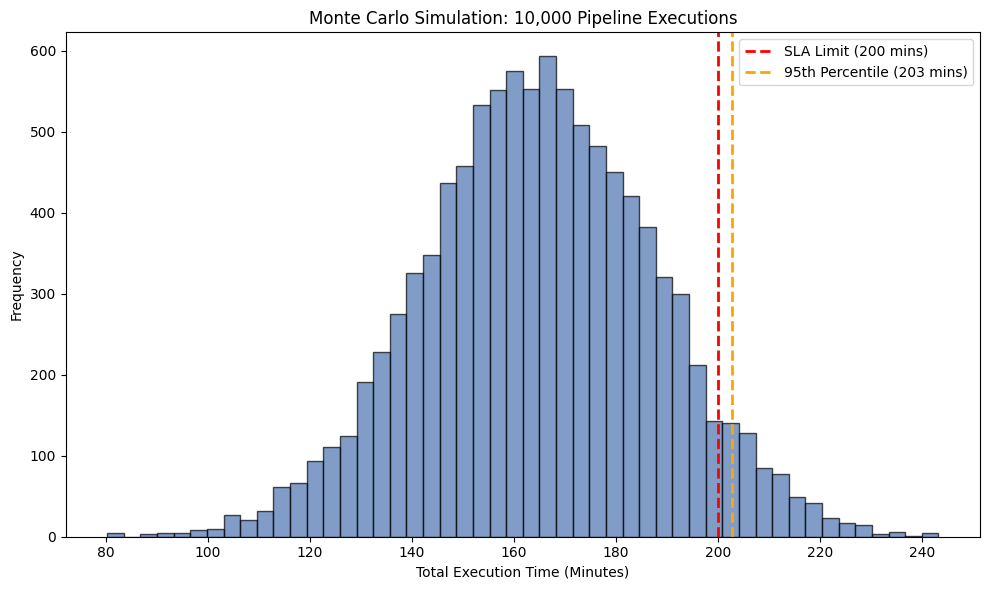

In [34]:
# Visualizing
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the distribution of our 10,000 simulated outcomes
ax.hist(total_pipeline_times, bins=50, color='#4C72B0', edgecolor='black', alpha=0.7)

# Overlay the SLA boundary as a harsh red line
ax.axvline(sla_limit, color='red', linestyle='--', linewidth=2, label=f'SLA Limit ({sla_limit} mins)')
ax.axvline(worst_case_95, color='orange', linestyle='--', linewidth=2, label=f'95th Percentile ({worst_case_95:.0f} mins)')

ax.set_title(f'Monte Carlo Simulation: {simulations:,} Pipeline Executions')
ax.set_xlabel('Total Execution Time (Minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('monte_carlo_simulation.png')
plt.show()